# Comparison between GradientBoostingClassifier and XGBClassifier as two variants of the CID_SID ML model 


### Content   <a name="content"></a>

1. [Load and analyse PubChem BioAssay data](#1)
2. [Create a data frame with CIDs and targets](#2)
3. [Reduce the inactive compounds](#3)
4. [Ensure equal number of both targets](#4)
5. [Balancing](#5)
6. [Comparison](#6)

### Load and analyse PubChem BioAssay data <a name="1"></a>

In [1]:
import pandas as pd 

# load the PubChem AID 686978 bioassy dataset
# https://pubchem.ncbi.nlm.nih.gov/bioassay/686978
df = pd.read_csv('AID_686978_data.csv', low_memory=False, on_bad_lines='skip')

# To avoid truncation of some columns during data frame display
pd.set_option('display.max_columns', None) 

# Display the data frame
print('Shape of the data frame: ', df.shape)
df.head()

Shape of the data frame:  (424003, 48)


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Phenotype,Potency,Efficacy,Analysis Comment,Activity_Score,Curve_Description,Fit_LogAC50,Fit_HillSlope,Fit_R2,Fit_InfiniteActivity,Fit_ZeroActivity,Fit_CurveClass,Excluded_Points,Max_Response,Activity at 0.0000295000 uM,Activity at 0.0000590000 uM,Activity at 0.0001503265 uM,Activity at 0.0002712146 uM,Activity at 0.0005895491 uM,Activity at 0.00117 uM,Activity at 0.00179 uM,Activity at 0.00299 uM,Activity at 0.00672 uM,Activity at 0.014 uM,Activity at 0.026 uM,Activity at 0.040 uM,Activity at 0.074 uM,Activity at 0.167 uM,Activity at 0.363 uM,Activity at 0.628 uM,Activity at 0.975 uM,Activity at 1.849 uM,Activity at 4.119 uM,Activity at 9.037 uM,Activity at 15.83 uM,Activity at 21.08 uM,Activity at 46.23 uM,Activity at 92.54 uM,Activity at 165.6 uM,Compound QC;;;;
0,1,109967258,50897788.0,CNCC1=NC2=C(C=C(C=C2)Cl)C(=N1)C3=CC=CN3,Active,42,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,14.1254,136.5470,NaN,42.0,Partial curve; high efficacy,-4.850,1.0100,0.9948,-134.4880,2.0597,-2.1,0 0 0 0 0,-106.3110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0597,NaN,NaN,NaN,NaN,0.5007,NaN,NaN,-17.4373,NaN,-48.5138,NaN,NaN,-106.3110,NaN,NaN,QC'd by AA Pharmaceuticals;;;
1,2,144206324,65628.0,CN1C2=C(C=C(C=C2)N(CCCl)CCCl)N=C1CCCC(=O)O,Active,41,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,18.8375,82.1468,NaN,41.0,Partial curve; high efficacy,-4.725,1.9887,0.9829,-82.6097,-0.4629,-2.1,0 0 0 0 0 0 0 0,-70.9545,NaN,NaN,NaN,NaN,-3.2819,NaN,NaN,1.1641,NaN,5.8554,NaN,NaN,-1.8326,NaN,-4.9853,NaN,NaN,0.0798,NaN,-16.3921,NaN,NaN,-70.9545,NaN,NaN,QC'd by ACC;;;
2,3,144206325,14708.0,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C)O)CC[C@@...,Inconclusive,10,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,21.1360,39.2903,NaN,10.0,Single point of activity,-4.675,2.7868,0.9357,-43.4549,-4.1646,-3.0,0 0 0 0 0 0 0 0,-39.2270,NaN,NaN,NaN,NaN,-4.1400,NaN,NaN,-5.7369,NaN,0.1681,NaN,NaN,-8.2838,NaN,-6.9258,NaN,NaN,1.0188,NaN,-7.8647,NaN,NaN,-39.2270,NaN,NaN,QC'd by ACC;;;;
3,4,144206326,3085168.0,CC1=NC=C(C(=N1)N)CN(C=O)/C(=C(\CCO)/SS/C(=C(/C...,Inactive,0,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inactive,NaN,NaN,NaN,0.0,NaN,NaN,4.9549,0.6177,2.0768,-13.6113,4.0,0 0 0 0 0 0 0 1,-5.7844,NaN,NaN,NaN,NaN,-11.9232,NaN,NaN,-14.5799,NaN,8.2225,NaN,NaN,4.9756,NaN,4.8996,NaN,NaN,-10.1081,NaN,3.3805,NaN,NaN,-5.7844,NaN,NaN,QC'd by ACC;;;;
4,5,144206327,2449.0,CC1=C(C(=O)C(=C(C1=O)C)C(CCCCCC(=O)O)C2=CC=CC=...,Inconclusive,10,http://assay.nih.gov/htsws/rest/display/dd-tdp...,NaN,Inhibitor,26.6086,77.9682,NaN,10.0,Single point of activity,-4.575,3.5117,0.9609,-82.1111,-4.1429,-3.0,0 0 0 0 0 0 0 0,-72.3569,NaN,NaN,NaN,NaN,-10.6429,NaN,NaN,-2.5661,NaN,-11.5870,NaN,NaN,-4.3838,NaN,1.2149,NaN,NaN,1.7567,NaN,-5.8883,NaN,NaN,-72.3569,NaN,NaN,QC'd by ACC;;;;


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424003 entries, 0 to 424002
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   PUBCHEM_RESULT_TAG             424003 non-null  int64  
 1   PUBCHEM_SID                    424003 non-null  int64  
 2   PUBCHEM_CID                    423975 non-null  float64
 3   PUBCHEM_EXT_DATASOURCE_SMILES  423975 non-null  object 
 4   PUBCHEM_ACTIVITY_OUTCOME       424003 non-null  object 
 5   PUBCHEM_ACTIVITY_SCORE         424003 non-null  int64  
 6   PUBCHEM_ACTIVITY_URL           424003 non-null  object 
 7   PUBCHEM_ASSAYDATA_COMMENT      0 non-null       float64
 8   Phenotype                      424003 non-null  object 
 9   Potency                        175189 non-null  float64
 10  Efficacy                       175189 non-null  float64
 11  Analysis Comment               0 non-null       float64
 12  Activity_Score                

In [3]:
# Remive missing values
df = df[df['PUBCHEM_CID'].notna()]
df.shape

(423975, 48)

In [4]:
# Remove duplicates without keeping a sample ofthem and reset the indexes 
df = df.drop_duplicates(subset='PUBCHEM_CID', keep=False).reset_index(drop=True)
df.shape

(410564, 48)

In [5]:
# Turn CID float data type into integer
df['PUBCHEM_CID'] = df['PUBCHEM_CID'].astype('int64') 

In [6]:
# Filter inhibitors 
df = df[['PUBCHEM_CID',
         'PUBCHEM_SID',
         'PUBCHEM_ACTIVITY_OUTCOME']] 
df.shape # 646675

(410564, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410564 entries, 0 to 410563
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   PUBCHEM_CID               410564 non-null  int64 
 1   PUBCHEM_SID               410564 non-null  int64 
 2   PUBCHEM_ACTIVITY_OUTCOME  410564 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.4+ MB


[<a href="#content">Back to top</a>]

## Create a data frame with CIDs and targets <a name="2"></a>

In [8]:
df['PUBCHEM_ACTIVITY_OUTCOME'] = df['PUBCHEM_ACTIVITY_OUTCOME'].astype(str) 
# Get unique values from 'column1'
unique_values = df['PUBCHEM_ACTIVITY_OUTCOME'].unique()
unique_values 

array(['Active', 'Inconclusive', 'Inactive'], dtype=object)

In [9]:
df.rename(columns={'PUBCHEM_CID':'CID',
                   'PUBCHEM_SID':'SID',
                   'PUBCHEM_ACTIVITY_OUTCOME':'target'}, inplace=True)

# Set the option to explicitly handle downcasting
pd.set_option('future.no_silent_downcasting', True)

# Create a mapping dictionary to replace string values with numeric values
mapping = {'Active': 1, 'Inactive': 0, 'Inconclusive':2}

# Replace string values with numeric values using the mapping dictionary
df['target'] = df['target'].replace(mapping)

# Display the data frame
print('Shape of the data frame: ', df.shape)
df.head()

Shape of the data frame:  (410564, 3)


,CID,SID,target
0,50897788,109967258,1
1,65628,144206324,1
2,14708,144206325,2
3,3085168,144206326,0
4,2449,144206327,2


In [10]:
# Turn CID float data type into integer
df['target'] = pd.to_numeric(df['target']) 

In [11]:
df['target'].value_counts()

target
0    236226
2    112867
1     61471
Name: count, dtype: int64

In [12]:
df_1 = df[df['target']==1]
df_1.shape

(61471, 3)

[<a href="#content">Back to top</a>]

## Reduce the inactive compounds <a name="3"></a>

In [13]:
# load the water solunility data 
df_sol = pd.read_csv('AID_1996_data.csv')

# Display the data frame
print('Shape of the data frame: ', df_sol.shape)
df_sol.head()

Shape of the data frame:  (57859, 30)


,PUBCHEM_RESULT_TAG,SID,CID,PUBCHEM_EXT_DATASOURCE_SMILES,OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,Solubility at pH 7.4_Qualifier_Mean,Solubility at pH 7.4_Mean,Test Concentration_1,Solubility at pH 7.4_Qualifier_1,Solubility at pH 7.4_1,Solubility at pH 7.4_Comment_1,Solubility of Astemizole at pH 7.4_Qualifier_1,Solubility of Astemizole at pH 7.4_1,Solubility of Sulfamethizole at pH 7.4_Qualifier_1,Solubility of Sulfamethizole at pH 7.4_1,Solubility of Imipramine HCl at pH 7.4_Qualifier_1,Solubility of Imipramine HCl at pH 7.4_1,Test Concentration_2,Solubility at pH 7.4_Qualifier_2,Solubility at pH 7.4_2,Solubility at pH 7.4_Comment_2,Solubility of Astemizole at pH 7.4_Qualifier_2,Solubility of Astemizole at pH 7.4_2,Solubility of Sulfamethizole at pH 7.4_Qualifier_2,Solubility of Sulfamethizole at pH 7.4_2,Solubility of Imipramine HCl at pH 7.4_Qualifier_2,Solubility of Imipramine HCl at pH 7.4_2
0,1,24826444,2374148,COC1=CC=C(C=C1)OCC2=NNC(=S)N2N,Active,40,NaN,NaN,=,10.85,200,<,0.1,Below LOQ,=,14.2,>,40.5,>,47.5,200.0,=,21.6,NaN,=,27.7,>,40.5,>,47.5
1,2,49669186,5295761,CC1=CC(=C(C=C1)NC2=NC3=CC=CC=C3N4C2=NN=C4)Cl,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,12.3,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,49669768,22431387,CC1=CC(=CC=C1)CCNC2=NC3=C(C=C(C=C3)C)N4C2=NN=C4,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,12.3,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,8139962,14296,CC1=C(N=C(C(=N1)C)C)C,Inactive,0,NaN,NaN,<,0.10,200,<,0.1,Below LOQ,=,11.4,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,24803435,865684,CC1=CC2=NC(=C(C=C2C=C1)C#N)NC3=CC=CC=C3OC,Inactive,0,NaN,NaN,<,0.20,200,<,0.2,Below LOQ,=,11.4,>,40.5,>,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Keep only the CID values 
df_sol = df_sol["CID"]

# Reduce values keeping only the common for both datasets CID
df = pd.merge(df, df_sol, on="CID")

# Display the data frame
print('Shape of the data frame: ', df_sol.shape)

Shape of the data frame:  (57859,)


In [15]:
df['target'].value_counts()

target
0    40405
2    12015
1     4430
Name: count, dtype: int64

In [16]:
# CSeparate target 0 compounds
df_0 = df[df['target']==0]

# Display the data frame
print('Shape of df_0: ', df_0.shape)

Shape of df_0:  (40405, 3)


In [17]:
# Concatenate target 1 and 0 compounds 
df = pd.concat([df_0, df_1])

In [18]:
# Count each of the binary targets
df['target'].value_counts()

target
1    61471
0    40405
Name: count, dtype: int64

In [19]:
# Shuffle the resulting data set
df = df.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Display the data frame
print('Shape of df: ', df.shape)

Shape of df:  (101876, 3)


In [20]:
df.to_csv("CIDs_targets_TDP1_II.csv")

[<a href="#content">Back to top</a>]

## Ensure equal number of both targets  <a name="4"></a>

In [21]:
# Handle the part of target 1 in the test set 
df_1 = df[df['target']==1]

# Shuffle the resulting data set
df_1 = df_1.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Extract 2800 samples (10% of 28000 samples) of target 1 for the test set
df_1_test = df_1.iloc[:11000] 

# Assign the rest of target 1 for the train set
df_1_train = df_1.iloc[11000:]

In [22]:
# Handle the part of target 0 in the test set 
df_0 = df[df['target']==0]

# Shuffle the resulting data set
df_0 = df_0.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

## Extract 10% of the target 0 for  the test set
df_0_test = df_0.iloc[:11000]

# Assign the rest of target 1 for the train set
df_0_train = df_0.iloc[11000:]

In [23]:
# Create train and test dataframe for further manipulation 
train = pd.concat([df_0_train, df_1_train])
test = pd.concat([df_0_test, df_1_test])

In [24]:
# Create the sets for ML 
X_train = train.drop(columns='target', axis=1)
y_train = train['target']
X_test =  test.drop(columns='target', axis=1)
y_test = test['target']

In [25]:
# Create the sets for Cross-validation
X = pd.concat([X_train, X_test])
y = pd.concat([y_train,y_test])

In [26]:
# Check the number of classes in the y_test set
y_test.value_counts()

target
0    11000
1    11000
Name: count, dtype: int64

In [27]:
# Print the shape of each part
print("Shapes:")
print("X_train: ", X_train.shape)
print("X_test:  ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test:  ", y_test.shape)

Shapes:
X_train:  (79876, 2)
X_test:   (22000, 2)
y_train:  (79876,)
y_test:   (22000,)


[<a href="#content">Back to top</a>]

## Balancing <a name="5"></a>

[(0, 29405), (1, 50471)]


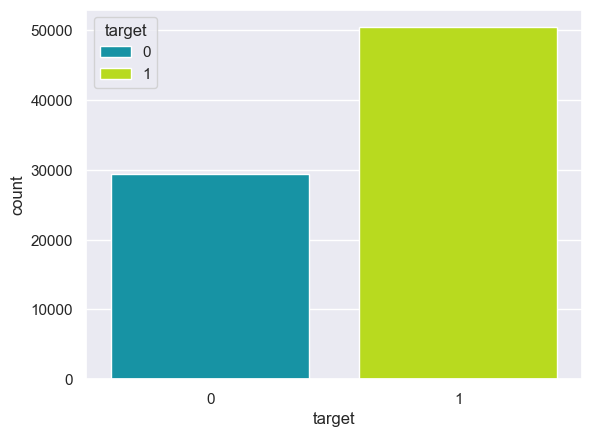

In [28]:
from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

# Illustrate the imbalance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train, palette='nipy_spectral')
plt.show()

[(0, 50471), (1, 50471)]


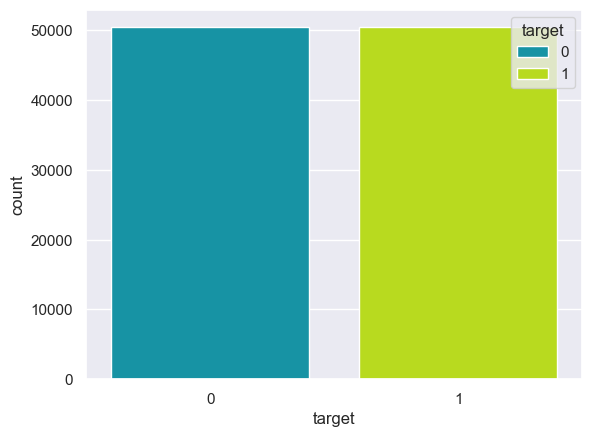

In [29]:
# from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler

# Balance targets with Synthetic Minority Oversampling Technique
# smote = SMOTE(random_state=0)
ros = RandomOverSampler()

X_train, y_train = ros.fit_resample(X_train, y_train)

# Illustrate the balance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train,palette='nipy_spectral')
plt.show()

In [30]:
# Print the shape of each part
print("Shapes:")
print("X_train: ", X_train.shape)
print("X_test:  ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test:  ", y_test.shape)

Shapes:
X_train:  (100942, 2)
X_test:   (22000, 2)
y_train:  (100942,)
y_test:   (22000,)


[<a href="#content">Back to top</a>]

## Comparison between GradientBoostingClassifier and XGBClassifier <a name="6"></a>

In [32]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

# Set random seed for reproducibility
np.random.seed(42)

# All data preparation happens in the main block below.
def train_and_predict(X_train, X_test, y_train, y_test):
    """Trains two models and generates predictions on the shared test set."""
    print("\n--- 2. Model Training and Prediction ---")
    
    # Model A: Gradient Boosting Classifier
    model_A = GradientBoostingClassifier(n_estimators=100, random_state=42)
    model_A.fit(X_train, y_train)
    y_pred_A = model_A.predict(X_test)
    
    # Model B: XGBoost Classifier
    model_B = XGBClassifier(eval_metric='logloss', random_state=42)
    # The y_train is passed as a 1D array (ravelled)
    model_B.fit(X_train, y_train)
    y_pred_B = model_B.predict(X_test)
    
    acc_A = accuracy_score(y_test, y_pred_A)
    acc_B = accuracy_score(y_test, y_pred_B)

    print(f"Model A (GradientBoostingClassifier) Accuracy: {acc_A:.4f}")
    print(f"Model B (XGBoost) Accuracy: {acc_B:.4f}")
    
    return y_pred_A, y_pred_B

def perform_mcnemar_test(y_true, y_pred_A, y_pred_B, alpha=0.05):
    """
    Performs McNemar's Test to statistically compare two models.
    """
    print("\n--- 3. Statistical Comparison (McNemar's Test) ---")
    
    # n_01: Count where Model A was CORRECT and Model B was WRONG
    n_01 = np.sum((y_pred_A == y_true) & (y_pred_B != y_true))
    
    # n_10: Count where Model A was WRONG and Model B was CORRECT
    n_10 = np.sum((y_pred_A != y_true) & (y_pred_B == y_true))
    
    # Calculate the full 2x2 table for statsmodels
    n_00 = np.sum((y_pred_A == y_true) & (y_pred_B == y_true))
    n_11 = np.sum((y_pred_A != y_true) & (y_pred_B != y_true))
    
    contingency_table = np.array([[n_00, n_01],
                                  [n_10, n_11]])
    
    print(f"Disagreement Counts (A Correct/B Wrong): n_01 = {n_01}")
    print(f"Disagreement Counts (A Wrong/B Correct): n_10 = {n_10}")
    
    # Perform the test
    result = mcnemar(contingency_table, exact=False)
    p_value = result.pvalue

    # 4. Interpret the Results
    print(f"\nSignificance Level (alpha): {alpha}")
    print(f"McNemar's Test P-value: {p_value:.4f}")
    
    if p_value < alpha:
        conclusion = "The difference in performance is **STATISTICALLY SIGNIFICANT**."
        if n_01 > n_10:
            conclusion += " (Model A is significantly better than Model B.)"
        else:
            conclusion += " (Model B is significantly better than Model A.)"
    else:
        conclusion = "The difference in performance is **NOT STATISTICALLY SIGNIFICANT**."
        conclusion += " (The observed difference is likely due to random chance.)"

    print("\nConclusion:")
    print(conclusion)

if __name__ == '__main__':
    print("--- 1. Data Preparation and Split ---")

    # y_true is just the true labels from the test set
    y_true = y_test 
    
    print(f"Total Samples: {len(df)}")
    print(f"Training Samples: {len(X_train)}")
    print(f"Testing Samples (Shared Test Set): {len(X_test)}")
    
    # Train and Get Predictions
    y_pred_A, y_pred_B = train_and_predict(X_train, X_test, y_train, y_test) 
    
    # Perform Statistical Comparison
    perform_mcnemar_test(y_true, y_pred_A, y_pred_B)


--- 1. Data Preparation and Split ---
Total Samples: 101876
Training Samples: 100942
Testing Samples (Shared Test Set): 22000

--- 2. Model Training and Prediction ---


NameError: name 'accuracy_score' is not defined

[<a href="#content">Back to top</a>]